# Model Validation and Baseline vs Engineered Model Comparison

This notebook validates the Probability of Default model using standard credit risk evaluation methods.

The objective is to compare:

1. Baseline model using raw application data
2. Improved model using engineered financial risk features

The validation techniques include:

- ROC-AUC
- Gini Coefficient
- KS Statistic
- Risk Decile Analysis
- Threshold Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
app_train = pd.read_csv("../data/raw/application_train.csv")

app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df = app_train.copy()

df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["CREDIT_ANNUITY_RATIO"] = df["AMT_CREDIT"] / df["AMT_ANNUITY"]

df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

df["DAYS_EMPLOYED_CLEAN"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED_CLEAN"] / 365
df["EMPLOYMENT_AGE_RATIO"] = df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]

df["INCOME_PER_FAMILY_MEMBER"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
df["INCOME_PER_CHILD"] = df["AMT_INCOME_TOTAL"] / (df["CNT_CHILDREN"] + 1)

external_score_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXT_SOURCE_MEAN"] = df[external_score_cols].mean(axis=1)

document_cols = [col for col in df.columns if col.startswith("FLAG_DOCUMENT")]
df["DOCUMENT_COUNT"] = df[document_cols].sum(axis=1)

df = df.replace([np.inf, -np.inf], np.nan)

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,AGE_YEARS,DAYS_EMPLOYED_CLEAN,EMPLOYMENT_YEARS,EMPLOYMENT_AGE_RATIO,INCOME_PER_FAMILY_MEMBER,INCOME_PER_CHILD,EXT_SOURCE_MEAN,DOCUMENT_COUNT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.121978,16.461104,25.920548,-637.0,1.745205,0.067329,202500.0,202500.0,0.161787,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.132217,36.234085,45.931507,-1188.0,3.254795,0.070862,135000.0,270000.0,0.466757,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.100000,20.000000,52.180822,-225.0,0.616438,0.011814,67500.0,67500.0,0.642739,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.219900,10.532818,52.068493,-3039.0,8.326027,0.159905,67500.0,135000.0,0.650442,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.179963,23.461618,54.608219,-3038.0,8.323288,0.152418,121500.0,121500.0,0.322738,1


In [4]:
target = "TARGET"

y = df[target]

y.value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [5]:
engineered_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO",
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "EMPLOYMENT_AGE_RATIO",
    "INCOME_PER_FAMILY_MEMBER",
    "INCOME_PER_CHILD",
    "EXT_SOURCE_MEAN",
    "DOCUMENT_COUNT"
]

baseline_X = app_train.drop(columns=[target])

engineered_X = df.drop(columns=[target])

print("Baseline feature count:", baseline_X.shape[1])
print("Engineered feature count:", engineered_X.shape[1])

Baseline feature count: 121
Engineered feature count: 132


In [6]:
def train_logistic_model(X, y):
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
    categorical_features = X.select_dtypes(include=["object"]).columns
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )
    
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]
    )
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )
    
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="saga"
            ))
        ]
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    return model, X_test, y_test, y_pred, y_pred_proba

In [7]:
baseline_model, X_test_base, y_test_base, y_pred_base, y_proba_base = train_logistic_model(
    baseline_X,
    y
)

C:\Users\gsard\AppData\Local\Temp\ipykernel_29388\3786049936.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns
c:\Users\gsard\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [8]:
engineered_model, X_test_eng, y_test_eng, y_pred_eng, y_proba_eng = train_logistic_model(
    engineered_X,
    y
)

C:\Users\gsard\AppData\Local\Temp\ipykernel_29388\3786049936.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns
c:\Users\gsard\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [9]:
def evaluate_model(y_test, y_pred, y_pred_proba, model_name):
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * roc_auc - 1
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
        "Gini": gini
    }

In [10]:
baseline_metrics = evaluate_model(
    y_test_base,
    y_pred_base,
    y_proba_base,
    "Baseline Model"
)

engineered_metrics = evaluate_model(
    y_test_eng,
    y_pred_eng,
    y_proba_eng,
    "Engineered Feature Model"
)

model_comparison = pd.DataFrame([baseline_metrics, engineered_metrics])

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Gini
0,Baseline Model,0.689853,0.161760,0.679557,0.261317,0.748344,0.496687
1,Engineered Feature Model,0.689560,0.160841,0.674723,0.259760,0.749152,0.498304


## Model Comparison Interpretation

ROC-AUC measures the model's ability to separate applicants who faced repayment difficulty from those who did not.

Gini is derived from ROC-AUC using:

Gini = 2 × ROC-AUC - 1

If the engineered feature model has a higher ROC-AUC and Gini than the baseline model, the engineered features improved model performance.

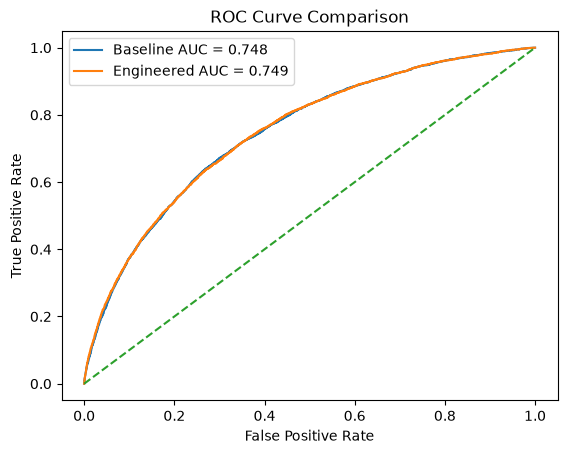

In [11]:
fpr_base, tpr_base, _ = roc_curve(y_test_base, y_proba_base)
fpr_eng, tpr_eng, _ = roc_curve(y_test_eng, y_proba_eng)

plt.plot(fpr_base, tpr_base, label=f"Baseline AUC = {baseline_metrics['ROC-AUC']:.3f}")
plt.plot(fpr_eng, tpr_eng, label=f"Engineered AUC = {engineered_metrics['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [12]:
def calculate_ks(y_test, y_pred_proba):
    validation_df = pd.DataFrame({
        "Actual_Default": y_test.values,
        "Predicted_PD": y_pred_proba
    })
    
    validation_df = validation_df.sort_values("Predicted_PD", ascending=False)
    
    validation_df["Cumulative_Defaults"] = validation_df["Actual_Default"].cumsum()
    validation_df["Cumulative_Non_Defaults"] = (1 - validation_df["Actual_Default"]).cumsum()
    
    total_defaults = validation_df["Actual_Default"].sum()
    total_non_defaults = (1 - validation_df["Actual_Default"]).sum()
    
    validation_df["Cumulative_Default_Rate"] = validation_df["Cumulative_Defaults"] / total_defaults
    validation_df["Cumulative_Non_Default_Rate"] = validation_df["Cumulative_Non_Defaults"] / total_non_defaults
    
    validation_df["KS"] = abs(
        validation_df["Cumulative_Default_Rate"] -
        validation_df["Cumulative_Non_Default_Rate"]
    )
    
    return validation_df["KS"].max()

In [13]:
baseline_ks = calculate_ks(y_test_base, y_proba_base)
engineered_ks = calculate_ks(y_test_eng, y_proba_eng)

ks_comparison = pd.DataFrame({
    "Model": ["Baseline Model", "Engineered Feature Model"],
    "KS Statistic": [baseline_ks, engineered_ks]
})

ks_comparison

,Model,KS Statistic
0,Baseline Model,0.371311
1,Engineered Feature Model,0.369063


In [14]:
def create_decile_summary(y_test, y_pred_proba):
    decile_df = pd.DataFrame({
        "Actual_Default": y_test.values,
        "Predicted_PD": y_pred_proba
    })
    
    decile_df["Risk_Decile"] = pd.qcut(
        decile_df["Predicted_PD"],
        q=10,
        labels=False,
        duplicates="drop"
    )
    
    decile_summary = decile_df.groupby("Risk_Decile").agg(
        Applicant_Count=("Actual_Default", "count"),
        Average_PD=("Predicted_PD", "mean"),
        Actual_Default_Rate=("Actual_Default", "mean")
    ).sort_values("Average_PD", ascending=False)
    
    return decile_summary

In [15]:
engineered_decile_summary = create_decile_summary(
    y_test_eng,
    y_proba_eng
)

engineered_decile_summary

,Applicant_Count,Average_PD,Actual_Default_Rate
Risk_Decile,,,
9,6151,0.792384,0.263209
8,6150,0.656966,0.145203
7,6150,0.566999,0.105691
6,6150,0.492372,0.080325
5,6150,0.426158,0.063902
4,6151,0.367459,0.045521
3,6150,0.313504,0.037561
2,6150,0.260543,0.031382
1,6150,0.204511,0.019024


## Risk Decile Interpretation

Risk decile analysis checks whether applicants with higher predicted Probability of Default actually show higher observed default rates.

A good credit risk model should show higher actual default rates in the highest-risk deciles and lower actual default rates in the lowest-risk deciles.

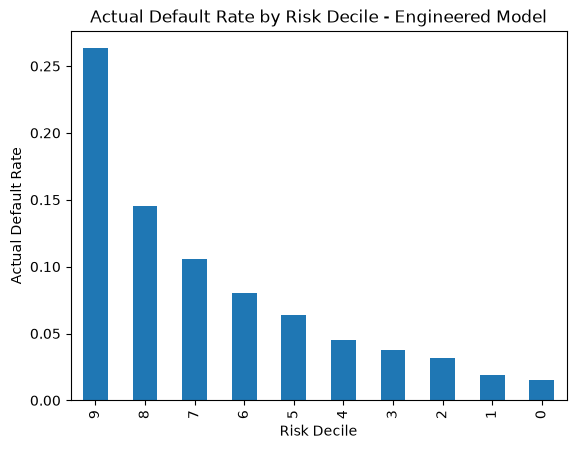

In [16]:
engineered_decile_summary["Actual_Default_Rate"].plot(kind="bar")

plt.title("Actual Default Rate by Risk Decile - Engineered Model")
plt.xlabel("Risk Decile")
plt.ylabel("Actual Default Rate")
plt.show()

In [17]:
thresholds_to_test = [0.10, 0.20, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds_to_test:
    predicted_class = (y_proba_eng >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_eng, predicted_class),
        "Precision": precision_score(y_test_eng, predicted_class, zero_division=0),
        "Recall": recall_score(y_test_eng, predicted_class, zero_division=0),
        "F1 Score": f1_score(y_test_eng, predicted_class, zero_division=0),
        "Predicted Default Rate": predicted_class.mean()
    })

threshold_summary = pd.DataFrame(threshold_results)

threshold_summary

,Threshold,Accuracy,Precision,Recall,F1 Score,Predicted Default Rate
0,0.1,0.099654,0.082147,0.997986,0.151798,0.980749
1,0.2,0.217941,0.091519,0.973212,0.167304,0.858462
2,0.3,0.389965,0.108444,0.907956,0.193747,0.675902
3,0.4,0.557908,0.133021,0.811279,0.228565,0.492350
4,0.5,0.689560,0.160841,0.674723,0.259760,0.338650


## Threshold Analysis Interpretation

The threshold determines when an applicant is classified as high risk.

A lower threshold captures more risky applicants but may also classify many safer applicants as risky.

A higher threshold is stricter but may miss some applicants who later face repayment difficulty.

The appropriate threshold depends on the lender's risk appetite and business strategy.

In [18]:
model_comparison.to_csv("../data/processed/model_comparison.csv", index=False)
ks_comparison.to_csv("../data/processed/ks_comparison.csv", index=False)
engineered_decile_summary.to_csv("../data/processed/engineered_decile_summary.csv")
threshold_summary.to_csv("../data/processed/threshold_analysis.csv", index=False)

## Final Model Validation Summary

This notebook compared the baseline Probability of Default model with a model that includes engineered financial risk features.

The validation used ROC-AUC, Gini coefficient, KS Statistic, risk decile analysis, and threshold analysis.

The model comparison helps determine whether engineered features improved the model's ability to separate applicants with repayment difficulty from those without repayment difficulty.

Risk decile analysis is especially useful in credit risk modelling because it shows whether higher-risk applicants are being ranked correctly by the model.

This validation step strengthens the project by moving it from basic modelling to a more complete credit risk modelling framework.